# Regressão Linear com Dados de Energia Solar (PVGIS)

**Objetivo:** estimar a potência produzida por um sistema fotovoltaico a partir de variáveis meteorológicas e solares, usando dados horários reais obtidos da API pública do **PVGIS** (Joint Research Centre, Comissão Europeia).

**Fonte dos dados:** PVGIS – ferramenta *Hourly Data / seriescalc* (documentação: https://joint-research-centre.ec.europa.eu/pvgis-photovoltaic-geographical-information-system_en). Não foi usado nenhum CSV pronto: os dados são obtidos por requisição HTTP.

| Nome completo | RM |
|---|---|
| Eduardo Barcelos De Carvalho Braziliano | 573274 |
| Julia Johanson Peniche Dias Da Silva | 572220 |
| Lucas Bomfim Leite | 570420 |

In [1]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.width", 140)

## 1. Requisição à API

Parâmetros mínimos do endpoint `seriescalc` :

| Parâmetro | Significado |
|---|---|
| `lat`, `lon` | latitude e longitude do local (graus decimais; sul e oeste são negativos) |
| `startyear`, `endyear` | **período** consultado (anos completos, dados horários) |
| `pvcalculation=1` | pede também a potência `P` do sistema FV (sem isso só vem irradiância) |
| `peakpower` | potência de pico instalada (kWp) |
| `loss` | perdas do sistema (%) |
| `optimalangles=1` | PVGIS calcula inclinação/orientação ótimas |
| `outputformat=json` | formato da resposta |

**Local escolhido:** São Paulo (SP).

In [2]:
cidade    = "São Paulo - SP"
latitude  = -23.5505
longitude = -46.6333
ano_ini, ano_fim = 2020, 2022

URL = "https://re.jrc.ec.europa.eu/api/v5_3/seriescalc"
params = {
    "lat": latitude, "lon": longitude,
    "startyear": ano_ini, "endyear": ano_fim,
    "pvcalculation": 1, "peakpower": 1, "loss": 14,
    "optimalangles": 1,
    "outputformat": "json",
}

resp = requests.get(URL, params=params, timeout=120)
resp.raise_for_status()
dados = resp.json()

print("Cidade:", cidade)
print("Latitude/Longitude:", latitude, longitude)
print("Período:", ano_ini, "a", ano_fim)
print("Endereço da requisição:", resp.url)
print("Chaves da resposta:", list(dados.keys()))
print("Variáveis disponíveis:", dados["meta"]["outputs"]["hourly"])

Cidade: São Paulo - SP
Latitude/Longitude: -23.5505 -46.6333
Período: 2020 a 2022
Endereço da requisição: https://re.jrc.ec.europa.eu/api/v5_3/seriescalc?lat=-23.5505&lon=-46.6333&startyear=2020&endyear=2022&pvcalculation=1&peakpower=1&loss=14&optimalangles=1&outputformat=json
Chaves da resposta: ['inputs', 'outputs', 'meta']
Variáveis disponíveis: {'type': 'time series', 'timestamp': 'hourly averages', 'variables': {'P': {'description': 'PV system power', 'units': 'W'}, 'G(i)': {'description': 'Global irradiance on the inclined plane (plane of the array)', 'units': 'W/m2'}, 'H_sun': {'description': 'Sun height', 'units': 'degree'}, 'T2m': {'description': '2-m air temperature', 'units': 'degree Celsius'}, 'WS10m': {'description': '10-m total wind speed', 'units': 'm/s'}, 'Int': {'description': '1 means solar radiation values are reconstructed'}}}


## 2. Organização dos dados em um DataFrame

A resposta é um JSON com três blocos (`inputs`, `outputs`, `meta`). Os dados horários estão em `outputs["hourly"]`. Variáveis (confirmadas em `meta`):

- `P`: potência FV (W) → **variável alvo**
- `G(i)`: irradiância no plano dos módulos (W/m²)
- `H_sun`: altura do Sol (graus)
- `T2m`: temperatura do ar a 2 m (°C)
- `WS10m`: velocidade do vento a 10 m (m/s)
- `Int`: indicador de dado de radiação reconstruído (não é útil aqui → descartado)

In [3]:
df = pd.DataFrame(dados["outputs"]["hourly"])
df["time"] = pd.to_datetime(df["time"], format="%Y%m%d:%H%M")
df = df[["time", "P", "G(i)", "H_sun", "T2m", "WS10m"]]
df.columns = ["data_hora", "potencia_W", "irradiancia_Wm2", "altura_solar_graus", "temp_C", "vento_ms"]
df.head()

,data_hora,potencia_W,irradiancia_Wm2,altura_solar_graus,temp_C,vento_ms
0,2020-01-01 00:03:00,0.0,0.0,0.0,22.79,1.72
1,2020-01-01 01:03:00,0.0,0.0,0.0,22.32,1.72
2,2020-01-01 02:03:00,0.0,0.0,0.0,21.90,1.59
3,2020-01-01 03:03:00,0.0,0.0,0.0,21.47,1.52
4,2020-01-01 04:03:00,0.0,0.0,0.0,21.18,1.52


## 3. Inspeção inicial do DataFrame

In [4]:
print("Linhas, colunas:", df.shape)
print("\nColunas:", list(df.columns))
print("\nTipos de dados e não-nulos:")
df.info()
print("\nValores ausentes por coluna:")
print(df.isnull().sum())
df.describe()

Linhas, colunas: (26304, 6)

Colunas: ['data_hora', 'potencia_W', 'irradiancia_Wm2', 'altura_solar_graus', 'temp_C', 'vento_ms']

Tipos de dados e não-nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26304 entries, 0 to 26303
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   data_hora           26304 non-null  datetime64[ns]
 1   potencia_W          26304 non-null  float64       
 2   irradiancia_Wm2     26304 non-null  float64       
 3   altura_solar_graus  26304 non-null  float64       
 4   temp_C              26304 non-null  float64       
 5   vento_ms            26304 non-null  float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 1.2 MB

Valores ausentes por coluna:
data_hora             0
potencia_W            0
irradiancia_Wm2       0
altura_solar_graus    0
temp_C                0
vento_ms              0
dtype: int64


,data_hora,potencia_W,irradiancia_Wm2,altura_solar_graus,temp_C,vento_ms
count,26304,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000
mean,2021-07-01 23:32:59.999999232,159.501989,209.477560,18.676292,19.334688,2.268036
min,2020-01-01 00:03:00,0.000000,0.000000,0.000000,2.070000,0.000000
25%,2020-09-30 23:48:00,0.000000,0.000000,0.000000,16.160000,1.380000
50%,2021-07-01 23:33:00,0.000000,0.000000,0.000000,19.225000,2.070000
75%,2022-04-01 23:18:00,282.225000,361.275000,36.820000,22.320000,2.970000
max,2022-12-31 23:03:00,852.460000,1130.470000,89.840000,35.870000,9.380000
std,NaN,241.095558,314.267833,24.327164,4.469007,1.204284


In [5]:
sem_irrad = (df["irradiancia_Wm2"] <= 0).sum()
sem_pot   = (df["potencia_W"] <= 0).sum()
print(f"Registros com irradiância = 0: {sem_irrad} ({sem_irrad/len(df):.1%})")
print(f"Registros com potência = 0:    {sem_pot} ({sem_pot/len(df):.1%})")
print(f"Registros com Sol abaixo do horizonte (altura <= 0): {(df['altura_solar_graus']<=0).sum()}")

Registros com irradiância = 0: 13371 (50.8%)
Registros com potência = 0:    13711 (52.1%)
Registros com Sol abaixo do horizonte (altura <= 0): 13371


### Decisão sobre registros noturnos

Durante a noite (e em alguns instantes do amanhecer/anoitecer) a irradiância é 0 e, por consequência, a potência também é 0. Esses registros representam uma fração grande do conjunto (aprox. metade das horas do ano). Mantê-los traria dois problemas:

1. A relação potência × irradiância fica dominada por milhares de pontos em (0, 0), o que **infla o R²** sem que o modelo tenha aprendido nada sobre a geração em si (prever zero à noite é trivial: basta saber que é noite).
2. Variáveis como temperatura e vento passariam a "explicar" a potência apenas por coincidirem com o ciclo dia/noite.

**Decisão:** manter apenas os registros com irradiância > 0, isto é, o modelo estima a potência **durante o período em que há geração**. Em produção, bastaria prever 0 W quando não houver Sol.

In [6]:
df_modelo = df[df["irradiancia_Wm2"] > 0].reset_index(drop=True)
print("Antes:", df.shape, "| Depois:", df_modelo.shape)
df_modelo.describe()

Antes: (26304, 6) | Depois: (12933, 6)


,data_hora,potencia_W,irradiancia_Wm2,altura_solar_graus,temp_C,vento_ms
count,12933,12933.000000,12933.000000,12933.000000,12933.000000,12933.000000
mean,2021-07-03 01:32:31.468336640,324.405808,426.049465,37.985092,21.409378,2.599155
min,2020-01-01 09:03:00,0.000000,0.930000,1.340000,2.070000,0.000000
25%,2020-10-08 11:03:00,74.260000,111.430000,20.380000,18.450000,1.590000
50%,2021-07-03 14:03:00,289.670000,371.610000,37.130000,21.660000,2.480000
75%,2022-03-27 20:03:00,557.820000,716.230000,52.510000,24.560000,3.520000
max,2022-12-31 21:03:00,852.460000,1130.470000,89.840000,35.870000,9.380000
std,NaN,254.415941,329.550895,21.684296,4.438948,1.339143


## 4. Definição do problema (X e y)

- **y** = `potencia_W` (potência produzida pelo sistema).
- Candidatas a **X**: `irradiancia_Wm2` (a energia solar disponível é o principal "combustível" do painel), `altura_solar_graus` (determina o ângulo de incidência e a massa de ar), `temp_C` (temperatura alta reduz a eficiência das células) e `vento_ms` (resfria os módulos). Colunas de data/hora não entram como variável numérica.

In [7]:
variaveis = ["irradiancia_Wm2", "altura_solar_graus", "temp_C", "vento_ms"]
y = df_modelo["potencia_W"]
X = df_modelo[variaveis]
print(X.shape, y.shape)

(12933, 4) (12933,)


## 5. Gráficos de dispersão (X × y)

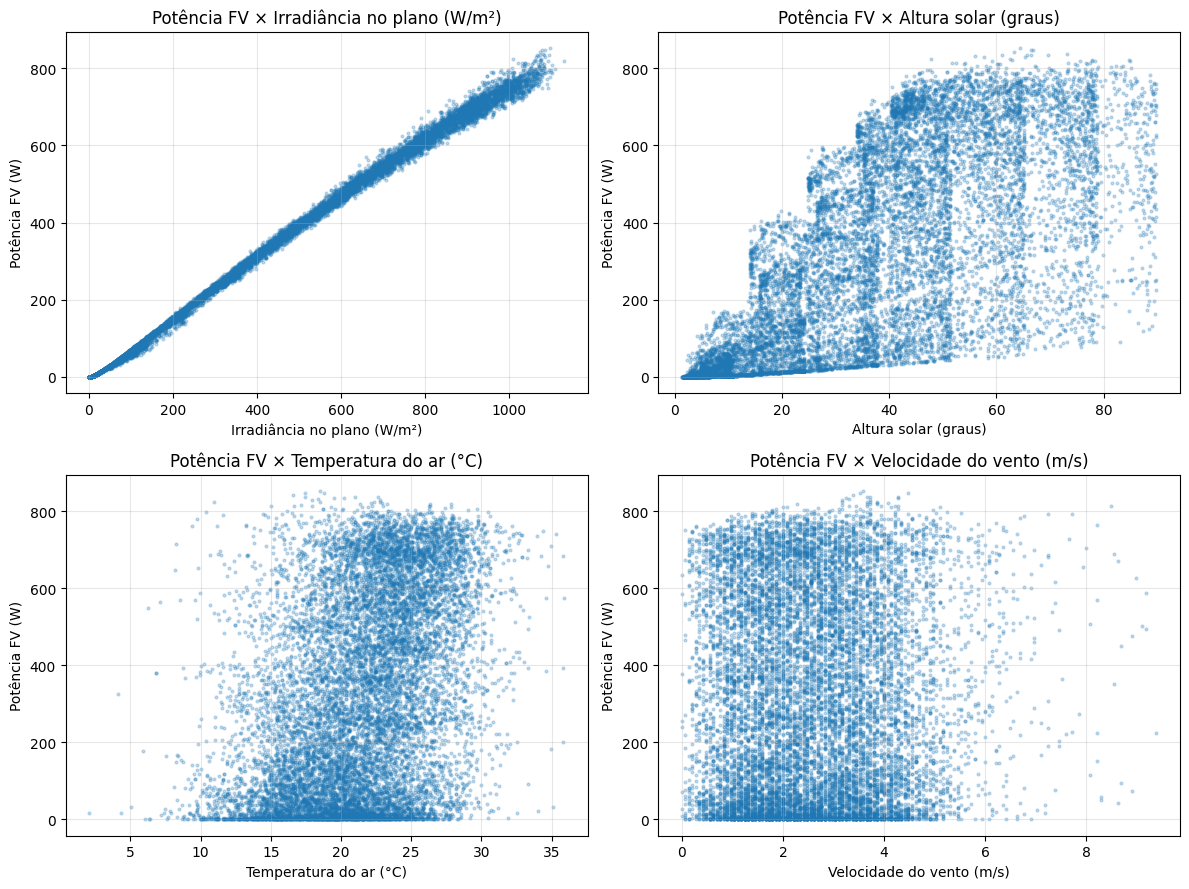

In [8]:
rotulos = {"irradiancia_Wm2": "Irradiância no plano (W/m²)",
           "altura_solar_graus": "Altura solar (graus)",
           "temp_C": "Temperatura do ar (°C)",
           "vento_ms": "Velocidade do vento (m/s)"}
fig, axs = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axs.ravel(), variaveis):
    ax.scatter(df_modelo[col], y, s=4, alpha=0.25)
    ax.set_title(f"Potência FV × {rotulos[col]}")
    ax.set_xlabel(rotulos[col]); ax.set_ylabel("Potência FV (W)")
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Matriz de correlação

,potencia_W,irradiancia_Wm2,altura_solar_graus,temp_C,vento_ms
potencia_W,1.000,0.998,0.675,0.387,0.013
irradiancia_Wm2,0.998,1.000,0.680,0.411,-0.007
altura_solar_graus,0.675,0.680,1.000,0.453,0.145
temp_C,0.387,0.411,0.453,1.000,-0.035
vento_ms,0.013,-0.007,0.145,-0.035,1.000


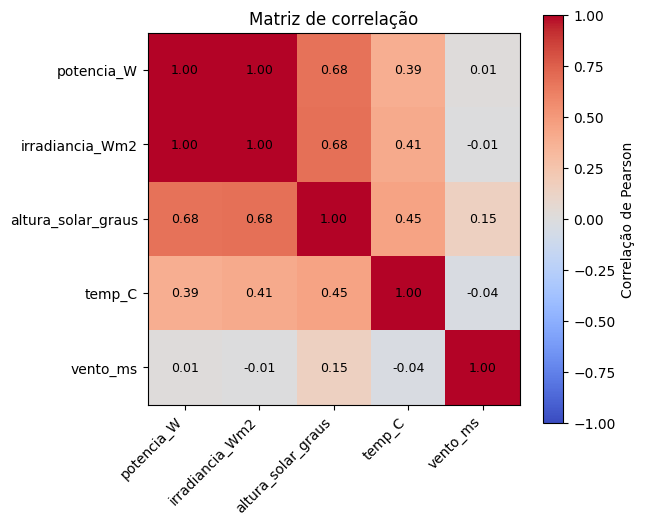

Correlação com a potência:
 irradiancia_Wm2       0.998
altura_solar_graus    0.675
temp_C                0.387
vento_ms              0.013
Name: potencia_W, dtype: float64

Maior correlação linear com y: irradiancia_Wm2
Correlações muito baixas (|r| < 0,2): ['vento_ms']


In [9]:
corr = df_modelo[["potencia_W"] + variaveis].corr()
display(corr.round(3))

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, label="Correlação de Pearson"); ax.set_title("Matriz de correlação")
plt.tight_layout(); plt.show()

corr_y = corr["potencia_W"].drop("potencia_W")
print("Correlação com a potência:\n", corr_y.sort_values(key=abs, ascending=False).round(3))
print("\nMaior correlação linear com y:", corr_y.abs().idxmax())
print("Correlações muito baixas (|r| < 0,2):", list(corr_y[corr_y.abs() < 0.2].index))

**Leitura:** a variável com maior |r| em relação à potência é apontada na saída acima (esperado: `irradiancia_Wm2`, pois a potência de um painel é aproximadamente proporcional à irradiância). Compare os valores da matriz com os gráficos de dispersão: uma correlação alta deve aparecer como uma "nuvem" estreita em torno de uma reta; correlação baixa aparece como nuvem espalhada sem tendência.

## 7. Separação treino/teste (80% / 20%)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)

X_train: (10346, 4) | X_test: (2587, 4)
y_train: (10346,) | y_test: (2587,)


## 8. Modelo 1 — todas as variáveis

In [11]:
vars1 = variaveis
modeloLR1 = LinearRegression()
modeloLR1.fit(X_train[vars1], y_train)
y_pred1 = modeloLR1.predict(X_test[vars1])

mae1 = mean_absolute_error(y_test, y_pred1)
mse1 = mean_squared_error(y_test, y_pred1)
r2_1 = r2_score(y_test, y_pred1)
print(f"MAE = {mae1:.3f} W | MSE = {mse1:.3f} W² | R² = {r2_1:.4f}")
print("Coeficientes:", dict(zip(vars1, modeloLR1.coef_.round(4))), "| Intercepto:", round(modeloLR1.intercept_, 3))

MAE = 9.296 W | MSE = 140.030 W² | R² = 0.9979
Coeficientes: {'irradiancia_Wm2': np.float64(0.7814), 'altura_solar_graus': np.float64(-0.0399), 'temp_C': np.float64(-1.531), 'vento_ms': np.float64(3.7771)} | Intercepto: 16.081


## 9. Modelo 2 — sem a irradiância

O segundo conjunto remove a variável de maior correlação (irradiância) para verificar quanto ela contribui. Usa-se **a mesma divisão** treino/teste (mesmo `random_state`), de modo que os modelos sejam comparados nas mesmas linhas.

In [12]:
vars2 = ["altura_solar_graus", "temp_C", "vento_ms"]
X_train2, X_test2, y_train2, y_test2 = train_test_split(X[vars2], y, test_size=0.2, random_state=42)
assert (y_test2.index == y_test.index).all()

modeloLR2 = LinearRegression()
modeloLR2.fit(X_train2, y_train2)
y_pred2 = modeloLR2.predict(X_test2)

mae2 = mean_absolute_error(y_test2, y_pred2)
mse2 = mean_squared_error(y_test2, y_pred2)
r2_2 = r2_score(y_test2, y_pred2)
print(f"MAE = {mae2:.3f} W | MSE = {mse2:.3f} W² | R² = {r2_2:.4f}")
print("Coeficientes:", dict(zip(vars2, modeloLR2.coef_.round(4))), "| Intercepto:", round(modeloLR2.intercept_, 3))

MAE = 148.383 W | MSE = 33562.598 W² | R² = 0.4862
Coeficientes: {'altura_solar_graus': np.float64(7.5569), 'temp_C': np.float64(5.1546), 'vento_ms': np.float64(-13.5546)} | Intercepto: -38.065


## 10. Tabela comparativa

In [13]:
comparacao = pd.DataFrame({
    "Modelo": ["Modelo 1", "Modelo 2"],
    "Variáveis utilizadas": [", ".join(vars1), ", ".join(vars2)],
    "MAE": [mae1, mae2],
    "MSE": [mse1, mse2],
    "R²": [r2_1, r2_2],
}).round(4)
comparacao

,Modelo,Variáveis utilizadas,MAE,MSE,R²
0,Modelo 1,"irradiancia_Wm2, altura_solar_graus, temp_C, v...",9.296,140.0298,0.9979
1,Modelo 2,"altura_solar_graus, temp_C, vento_ms",148.383,33562.5978,0.4862


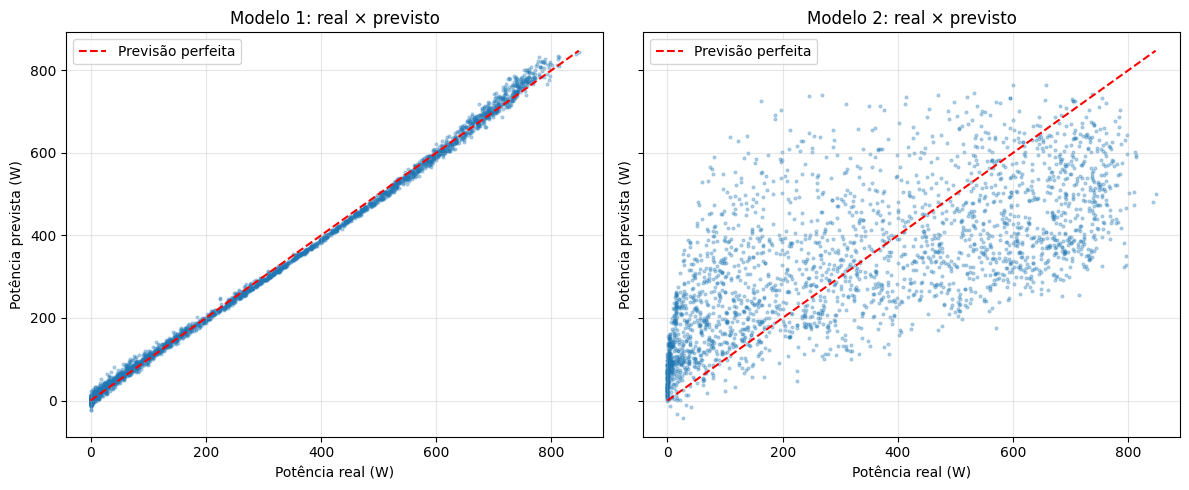

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, yp, nome in zip(axs, [y_pred1, y_pred2], ["Modelo 1", "Modelo 2"]):
    ax.scatter(y_test, yp, s=4, alpha=0.3)
    lim = [0, max(y_test.max(), yp.max())]
    ax.plot(lim, lim, "r--", label="Previsão perfeita")
    ax.set_title(f"{nome}: real × previsto"); ax.set_xlabel("Potência real (W)"); ax.set_ylabel("Potência prevista (W)")
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 11. Análise dos resultados

In [15]:
m = lambda col, melhor: comparacao.loc[getattr(comparacao[col], melhor)(), "Modelo"]
print("1. Maior R²:  ", m("R²", "idxmax"))
print("2. Menor MAE: ", m("MAE", "idxmin"))
print("3. Menor MSE: ", m("MSE", "idxmin"))
iguais = len({m("R²", "idxmax"), m("MAE", "idxmin"), m("MSE", "idxmin")}) == 1
print("4. As três métricas apontam para o mesmo modelo?", "Sim" if iguais else "Não")
top = corr_y.abs().idxmax()
print(f"5. Variável mais correlacionada: {top}. Ela está em {'Modelo 1' if top in vars1 else ''}"
      f"{' e Modelo 2' if top in vars2 else ''}. O modelo que a contém tem R² = "
      f"{r2_1:.3f} contra {r2_2:.3f} do outro.")

1. Maior R²:   Modelo 1
2. Menor MAE:  Modelo 1
3. Menor MSE:  Modelo 1
4. As três métricas apontam para o mesmo modelo? Sim
5. Variável mais correlacionada: irradiancia_Wm2. Ela está em Modelo 1. O modelo que a contém tem R² = 0.998 contra 0.486 do outro.


**5.** A saída acima mostra que o modelo que contém a variável de maior correlação (irradiância) tende a ser o melhor, o que é coerente. Porém, correlação alta não garante, por si só, o melhor modelo: variáveis correlacionadas entre si (por exemplo, irradiância e altura solar) trazem informação redundante, e uma variável com correlação baixa isolada (temperatura, vento) pode somar um pequeno ganho ao ser combinada com as demais. Conclua comparando os R² do Modelo 2 (sem irradiância) e do Modelo 1.

**6.** Observe o gráfico de dispersão potência × irradiância: a relação é aproximadamente linear, com dispersão causada principalmente pela temperatura (que reduz a eficiência) e por pequenas diferenças de ângulo de incidência. Já temperatura e vento mostram nuvens bastante dispersas, sem padrão linear claro; a altura solar tem relação crescente, porém curvada, nos valores baixos.

**7.** Fatores que dificultam a previsão por modelo linear:
- **Não linearidade:** a eficiência do módulo varia com a temperatura e com a irradiância (pior em baixa irradiância), e o ângulo de incidência afeta a geração de forma não linear.
- **Multicolinearidade:** irradiância e altura solar são muito correlacionadas.
- **Variáveis ausentes:** nebulosidade e aerossóis já estão embutidos na irradiância; sem ela o modelo perde quase toda a capacidade explicativa.
- **Dependência temporal:** dados horários são autocorrelacionados, e a divisão aleatória em treino/teste pode deixar o teste "parecido demais" com o treino (otimismo nas métricas).
- **Efeito dia/noite:** a presença de horas sem geração distorce a relação linear (por isso foram removidas).
- **Interações:** o efeito do vento depende da temperatura, algo que a regressão linear simples não captura.